#Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import kendalltau
from scipy.stats import spearmanr
import ndlib.models.ModelConfig as mc
#import ndlib.models.epidemics.SIRModel as sir
import ndlib.models.epidemics as sir
import os

# Global parameters for SIR model

In [4]:
MU = 1.0  # Recovery rate
ITERATIONS = 1000  # Number of iterations

# (1) Load network from CSV and create the network

In [7]:
def load_graph(csv_file):
    df = pd.read_csv(csv_file)
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(str(row.iloc[0]), str(row.iloc[1]))
    return G

# (2) Get the largest connected component

In [10]:
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()

# (3) Compute Beta Threshold using degree distribution

In [13]:
def get_largest_connected_component(G):
    if nx.is_connected(G):
        return G
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        return G.subgraph(largest_cc).copy()


# (3) Compute Beta Threshold using degree distribution

In [16]:
def compute_beta_threshold(G, mu):
    degrees = np.array([deg for _, deg in G.degree()])
    k_avg = np.mean(degrees)
    k2_avg = np.mean(degrees ** 2)
    if k2_avg == k_avg:
        return float('inf')  # Avoid division by zero
    beta_th = k_avg / (k2_avg - k_avg)
    return beta_th

# (4) SIR Epidemic Model Simulation using NDlib

In [19]:
#import ndlib.models.epidemics as sir
#import ndlib.models.ModelConfig as mc

def simulate_SIR(G, beta, mu, mc_runs=1000):
    """
    Computes the spreading influence of every node using
    a network-based SIR model in NDlib.

    Parameters
    ----------
    G : networkx.Graph
        Input network

    beta : float
        Infection probability

    mu : float
        Recovery probability

    mc_runs : int
        Number of independent Monte Carlo simulations
        for each seed node.

    Returns
    -------
    sir_scores : dict
        Average outbreak size for every node.
    """

    sir_scores = {}

    for seed in G.nodes():

        outbreak_sum = 0

        for run in range(mc_runs):

            # Create a fresh SIR model
            model = sir.SIRModel(G)

            config = mc.Configuration()

            config.add_model_parameter("beta", beta)
            config.add_model_parameter("gamma", mu)

            # Only the seed node is initially infected
            config.add_model_initial_configuration(
                "Infected",
                [seed]
            )

            model.set_initial_status(config)

            # Run until epidemic terminates
            while True:
            
                iteration = model.iteration()
                infected_count = iteration["node_count"][1]

                if infected_count == 0:
                    break

            # Final outbreak size
            outbreak_size = iteration["node_count"][2]

            outbreak_sum += outbreak_size

        sir_scores[seed] = outbreak_sum / mc_runs

    return sir_scores


In [21]:
# (4) SIR Epidemic Model Complete Implementation 
def simulate_SIR_Complete(G, beta, mu, mc_runs=1000):
    sir_scores = {node: 0 for node in G.nodes()}
    
    for _ in range(mc_runs):
        for node in G.nodes():
            status = {n: "S" for n in G.nodes()}
            status[node] = "I"  # Infect the initial node
            infected = {node}

            while infected:
                new_infected = set()
                new_recovered = set()

                for inf_node in infected:
                    for neighbor in G.neighbors(inf_node):
                        if status[neighbor] == "S" and random.random() < beta:
                            new_infected.add(neighbor)
                    
                    if random.random() < mu:
                        new_recovered.add(inf_node)

                for n in new_infected:
                    status[n] = "I"
                for n in new_recovered:
                    status[n] = "R"
                
                infected = new_infected

            sir_scores[node] += sum(1 for s in status.values() if s == "R")

    for node in sir_scores:
        sir_scores[node] /= mc_runs
    
    return sir_scores

In [23]:
#import ndlib.models.epidemics as sir
#import ndlib.models.ModelConfig as mc
#import numpy as np

def simulate_SIR_R1(G, beta, mu, mc_runs=1000):
    """
    Network-based SIR simulation using NDlib.
    This method is not required to be used
    it also returns average S,I,R average counts for SIR Dynamics plot over all nodes

    Parameters
    ----------
    G : NetworkX graph
    beta : Infection probability
    mu : Recovery probability
    mc_runs : Number of Monte Carlo runs for each seed node

    Returns
    -------
    sir_scores : dict
        Average outbreak size of every node.

    avg_S : numpy array
        Average number of susceptible nodes vs time.

    avg_I : numpy array
        Average number of infected nodes vs time.

    avg_R : numpy array
        Average number of recovered nodes vs time.
    """

    sir_scores = {}

    global_S = []
    global_I = []
    global_R = []

    for seed in G.nodes():

        outbreak_sum = 0

        seed_S = []
        seed_I = []
        seed_R = []

        for run in range(mc_runs):

            model = sir.SIRModel(G)

            config = mc.Configuration()
            config.add_model_parameter("beta", beta)
            config.add_model_parameter("gamma", mu)

            # Only one initially infected node
            config.add_model_initial_configuration("Infected", [seed])

            model.set_initial_status(config)

            S_curve = []
            I_curve = []
            R_curve = []

            while True:

                iteration = model.iteration()

                node_count = iteration["node_count"]

                S_curve.append(node_count[0])
                I_curve.append(node_count[1])
                R_curve.append(node_count[2])

                if node_count[1] == 0:
                    break

            outbreak_sum += R_curve[-1]

            seed_S.append(S_curve)
            seed_I.append(I_curve)
            seed_R.append(R_curve)

        sir_scores[seed] = outbreak_sum / mc_runs

        # Average curves for this seed
        max_len = max(len(x) for x in seed_S)

        S_avg = np.zeros(max_len)
        I_avg = np.zeros(max_len)
        R_avg = np.zeros(max_len)

        for s,i,r in zip(seed_S,seed_I,seed_R):

            if len(s)<max_len:
                s += [s[-1]]*(max_len-len(s))
                i += [i[-1]]*(max_len-len(i))
                r += [r[-1]]*(max_len-len(r))

            S_avg += np.array(s)
            I_avg += np.array(i)
            R_avg += np.array(r)

        S_avg /= mc_runs
        I_avg /= mc_runs
        R_avg /= mc_runs

        global_S.append(S_avg)
        global_I.append(I_avg)
        global_R.append(R_avg)

    ####################################################
    # Average over all seed nodes
    ####################################################

    max_len = max(len(x) for x in global_S)

    avg_S = np.zeros(max_len)
    avg_I = np.zeros(max_len)
    avg_R = np.zeros(max_len)

    for s,i,r in zip(global_S,global_I,global_R):

        if len(s)<max_len:
            s=np.pad(s,(0,max_len-len(s)),constant_values=s[-1])
            i=np.pad(i,(0,max_len-len(i)),constant_values=i[-1])
            r=np.pad(r,(0,max_len-len(r)),constant_values=r[-1])

        avg_S+=s
        avg_I+=i
        avg_R+=r

    avg_S/=len(global_S)
    avg_I/=len(global_I)
    avg_R/=len(global_R)

    return sir_scores, avg_S, avg_I, avg_R


In [25]:
import ndlib.models.epidemics as sir
import ndlib.models.ModelConfig as mc
import numpy as np

def simulate_Single_Seed_SIR_curve(G, seed_node, beta, mu, mc_runs=1000):
    """
    Generate average S-I-R curves for a single seed node.

    Parameters
    ----------
    G : NetworkX graph
    seed_node : node id
        Initial infected node.
    beta : infection probability
    mu : recovery probability
    mc_runs : number of Monte Carlo runs

    Returns
    -------
    avg_S, avg_I, avg_R
    """

    S_runs = []
    I_runs = []
    R_runs = []

    for run in range(mc_runs):

        model = sir.SIRModel(G)

        config = mc.Configuration()

        config.add_model_parameter("beta", beta)
        config.add_model_parameter("gamma", mu)

        config.add_model_initial_configuration(
            "Infected",
            [seed_node]
        )

        model.set_initial_status(config)

        S_curve = []
        I_curve = []
        R_curve = []

        while True:

            iteration = model.iteration()

            node_count = iteration["node_count"]

            S_curve.append(node_count[0])
            I_curve.append(node_count[1])
            R_curve.append(node_count[2])

            if node_count[1] == 0:
                break

        S_runs.append(S_curve)
        I_runs.append(I_curve)
        R_runs.append(R_curve)

    ###################################################
    # Average curves
    ###################################################

    max_len = max(len(x) for x in S_runs)

    avg_S = np.zeros(max_len)
    avg_I = np.zeros(max_len)
    avg_R = np.zeros(max_len)

    for s, i, r in zip(S_runs, I_runs, R_runs):

        s = np.pad(s,
                   (0, max_len-len(s)),
                   constant_values=s[-1])

        i = np.pad(i,
                   (0, max_len-len(i)),
                   constant_values=i[-1])

        r = np.pad(r,
                   (0, max_len-len(r)),
                   constant_values=r[-1])

        avg_S += s
        avg_I += i
        avg_R += r

    avg_S /= mc_runs
    avg_I /= mc_runs
    avg_R /= mc_runs

    return avg_S, avg_I, avg_R

In [27]:
import matplotlib.pyplot as plt

def plot_avg_SIR_vs_time(avg_S, avg_I, avg_R):

    plt.figure(figsize=(8,5))

    plt.plot(avg_S,
             linewidth=2,
             label='Susceptible')

    plt.plot(avg_I,
             linewidth=2,
             label='Infected')

    plt.plot(avg_R,
             linewidth=2,
             label='Recovered')

    plt.xlabel("Time Step")

    plt.ylabel("Average Number of Nodes")

    plt.title("Average SIR Dynamics")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()


In [29]:
#import matplotlib.pyplot as plt

def plot_Single_seed_SIR_curve(file_name, avg_S, avg_I, avg_R, title):

    plt.figure(figsize=(8,5))
    plt.plot(linewidth=2.5)
    plt.plot(avg_S,
             linewidth=2,
             label="Susceptible")

    plt.plot(avg_I,
             linewidth=2,
             label="Infected")

    plt.plot(avg_R,
             linewidth=2,
             label="Recovered")

    plt.xlabel("Time Step", fontsize=14)
    plt.ylabel("Number of Nodes", fontsize=14)

    #plt.title(f"SIR Dynamics (Seed Node = {seed_node})")
    plt.title(title)
    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()
    
    plt.savefig(
    os.path.join("Figures", f"SIR_dynamics_{file_name}.pdf"),
    bbox_inches="tight"
)
    plt.show()

# (5) Compute centrality values

In [32]:
def compute_centrality_measures(G, sir_scores=None):
    
    # NetworkX returns VoteRank as an ordered list:
    # first node = most influential
    voterank_list = nx.voterank(G)

    # Convert the ranking into descending scores
    voterank_scores = {
        node: len(voterank_list) - rank
        for rank, node in enumerate(voterank_list)
    }

    
    measures = {
        "Betweenness": nx.betweenness_centrality(G),
        "Closeness": nx.closeness_centrality(G),
        "K-Shell": nx.core_number(G),
        "PageRank": nx.pagerank(G),
        "Eigenvector": nx.eigenvector_centrality(G, max_iter=1000),
        "Katz": nx.katz_centrality(G, alpha=0.005, beta=1.0, max_iter=1000),
        "VoteRank": voterank_scores
        #"VoteRank": {n: i for i, n in enumerate(nx.voterank(G))}
    }
    if sir_scores is not None:
        measures["SIR_Score"] = sir_scores
    return measures




# (6) Save centrality scores to DataFrame

In [35]:
def centrality_df(G, sir_scores, centrality):
    data = {
        "Node": list(G.nodes()),
        "SIR_Score": [sir_scores.get(n, 0) for n in G.nodes()],
        "Betweenness": [centrality["Betweenness"].get(n, 0) for n in G.nodes()],
        "Closeness": [centrality["Closeness"].get(n, 0) for n in G.nodes()],
        "K-Shell": [centrality["K-Shell"].get(n, 0) for n in G.nodes()],
        "PageRank": [centrality["PageRank"].get(n, 0) for n in G.nodes()],
        "Eigenvector": [centrality["Eigenvector"].get(n, 0) for n in G.nodes()],
        "Katz": [centrality["Katz"].get(n, 0) for n in G.nodes()],
        "VoteRank": [centrality["VoteRank"].get(n, 0) for n in G.nodes()]
    }
    return pd.DataFrame(data)


In [37]:
# (7) Compute Kendall's Tau correlation
def compute_kendall_correlation(series1, series2):
    return kendalltau(series1, series2).correlation

# (7.1) Compute Spearman's Rank correlation
def compute_spearman_correlation(series1, series2):
    return spearmanr(series1, series2).correlation


# (7) Sort and Save two-column DataFrame
def save_sorted_df(df, column_name, filename):
    sorted_df = df[["Node", column_name]].sort_values(by=column_name, ascending=False)
    sorted_df.columns = ["Node_ID", column_name]  # Rename column for clarity
    sorted_df.to_csv(filename, index=False)
    return sorted_df

# (8) Get subgraph within max_distance from a node
def get_subgraph(G, node, max_distance):
    subgraph_nodes = {n for n in G.nodes() if nx.has_path(G, node, n) and nx.shortest_path_length(G, node, n) <= max_distance}
    return G.subgraph(subgraph_nodes)

# (9) Process subgraphs and compute centralities

In [40]:
def process_subgraphs(G, diameter_fraction):
    centrality_data = {
        "Node": [], "Betweenness": [], "Closeness": [],
        "K-Shell": [], "PageRank": [],
        "Eigenvector": [], "Katz": [], "VoteRank": []
    }

    for node in G.nodes():
        temp_network = get_subgraph(G, node, diameter_fraction)
        centrality_measures_sub = compute_centrality_measures(temp_network)

        centrality_data["Node"].append(node)
        centrality_data["Betweenness"].append(centrality_measures_sub["Betweenness"].get(node, 0))
        centrality_data["Closeness"].append(centrality_measures_sub["Closeness"].get(node, 0))
        centrality_data["K-Shell"].append(centrality_measures_sub["K-Shell"].get(node, 0))
        centrality_data["PageRank"].append(centrality_measures_sub["PageRank"].get(node, 0))
        centrality_data["Eigenvector"].append(centrality_measures_sub["Eigenvector"].get(node, 0))
        centrality_data["Katz"].append(centrality_measures_sub["Katz"].get(node, 0))
        centrality_data["VoteRank"].append(centrality_measures_sub["VoteRank"].get(node, 0))

    return pd.DataFrame(centrality_data)


In [42]:
# (10) Network Efficiency Calculation
def network_efficiency(G):
    n = len(G)
    if n < 2:
        return 0

    path_length = dict(nx.all_pairs_shortest_path_length(G))
    inv_dist_sum = 0
    count = 0
   
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                try:
                    dist = path_length[u][v]
                    inv_dist_sum += 1 / dist
                except KeyError:
                    # no path exists between u and v, contribute 0
                    pass
                count += 1

    efficiency = inv_dist_sum / count if count > 0 else 0
    return efficiency

# (11) Average Mean Path Length Calculat ion
def average_mean_path_length(G):
    if nx.is_connected(G):
        return nx.average_shortest_path_length(G)
    else:
        # Use largest connected component for disconnected graphs
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        return nx.average_shortest_path_length(subgraph)

In [44]:
# (10) Main Execution
import os
Network_Name="Metabolic"
csv_file = os.path.join("datasets", f"{Network_Name}_dataset.csv")
#csv_file = Network_Name+"_dataset.csv"
G = load_graph(csv_file)
G.remove_edges_from(nx.selfloop_edges(G))
G = get_largest_connected_component(G)
# Compute dynamic beta threshold
BETA_THRESHOLD = compute_beta_threshold(G, MU)
BETA = 1.5 * BETA_THRESHOLD  # Scaled beta

print(f"Computed Beta Threshold: {BETA_THRESHOLD:.6f}")
print(f"Using Beta Value: {BETA:.6f}")
#print(f"Network Efficiency: {network_efficiency(G):.6f}")
#print(f"Average Mean Path Length: {average_mean_path_length(G):.6f}")  

# Simulate SIR model and Plot S,I,R vs time plots
sir_scores = simulate_SIR(G, BETA, MU, ITERATIONS)

# Compute centralities for full network
centrality_D = compute_centrality_measures(G, sir_scores)
df_D = centrality_df(G, sir_scores, centrality_D)

df_D.to_csv(
    os.path.join("results", f"{Network_Name}_all_centrality.csv"),
    index=False
)
#df_D.to_csv(Network_Name+"_all_centrality.csv", index=False)

# Save sorted DataFrames by each centrality (two columns only)
save_sorted_df(df_D, "K-Shell", os.path.join("results", f"{Network_Name}_KS_D.csv"))
save_sorted_df(df_D, "Betweenness", "results/"+Network_Name+"_BC_D.csv")
save_sorted_df(df_D, "Closeness", "results/"+Network_Name+"_CC_D.csv")
save_sorted_df(df_D, "PageRank", "results/"+Network_Name+"_PR_D.csv")
save_sorted_df(df_D, "Eigenvector", "results/"+Network_Name+"_EV_D.csv")
save_sorted_df(df_D, "VoteRank", "results/"+Network_Name+"_VR_D.csv")
save_sorted_df(df_D, "Katz", "results/"+Network_Name+"_KZ_D.csv")
save_sorted_df(df_D, "SIR_Score", "results/"+Network_Name+"_SIR_D.csv")


# Compute diameter
diameter = nx.diameter(G)
print(f"Network:{Network_Name}, Diameter:{diameter}")
# Initialize result storage
kendall_results = []
spearman_results = []

# Iterate from distance 2 to D
for d in range(2, diameter + 1):
    print(f"Processing Diameter = {d}")
    df_sub = process_subgraphs(G, d)

    kendall_results.append({
        "Distance": d,
        "K-Shell": compute_kendall_correlation(df_D["SIR_Score"], df_sub["K-Shell"]),
        "Betweenness": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Betweenness"]),
        "Closeness": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Closeness"]),
        "PageRank": compute_kendall_correlation(df_D["SIR_Score"], df_sub["PageRank"]),
        "Eigenvector": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Eigenvector"]),
        "Katz": compute_kendall_correlation(df_D["SIR_Score"], df_sub["Katz"]),
        "VoteRank": compute_kendall_correlation(df_D["SIR_Score"], df_sub["VoteRank"])
    })

    spearman_results.append({
        "Distance": d,
        "K-Shell": compute_spearman_correlation(df_D["SIR_Score"], df_sub["K-Shell"]),
        "Betweenness": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Betweenness"]),
        "Closeness": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Closeness"]),
        "PageRank": compute_spearman_correlation(df_D["SIR_Score"], df_sub["PageRank"]),
        "Eigenvector": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Eigenvector"]),
        "Katz": compute_spearman_correlation(df_D["SIR_Score"], df_sub["Katz"]),
        "VoteRank": compute_spearman_correlation(df_D["SIR_Score"], df_sub["VoteRank"])
    })

Computed Beta Threshold: 0.025569
Using Beta Value: 0.038354
Network:Metabolic, Diameter:7
Processing Diameter = 2
Processing Diameter = 3
Processing Diameter = 4
Processing Diameter = 5
Processing Diameter = 6
Processing Diameter = 7


# Convert results to DataFrame

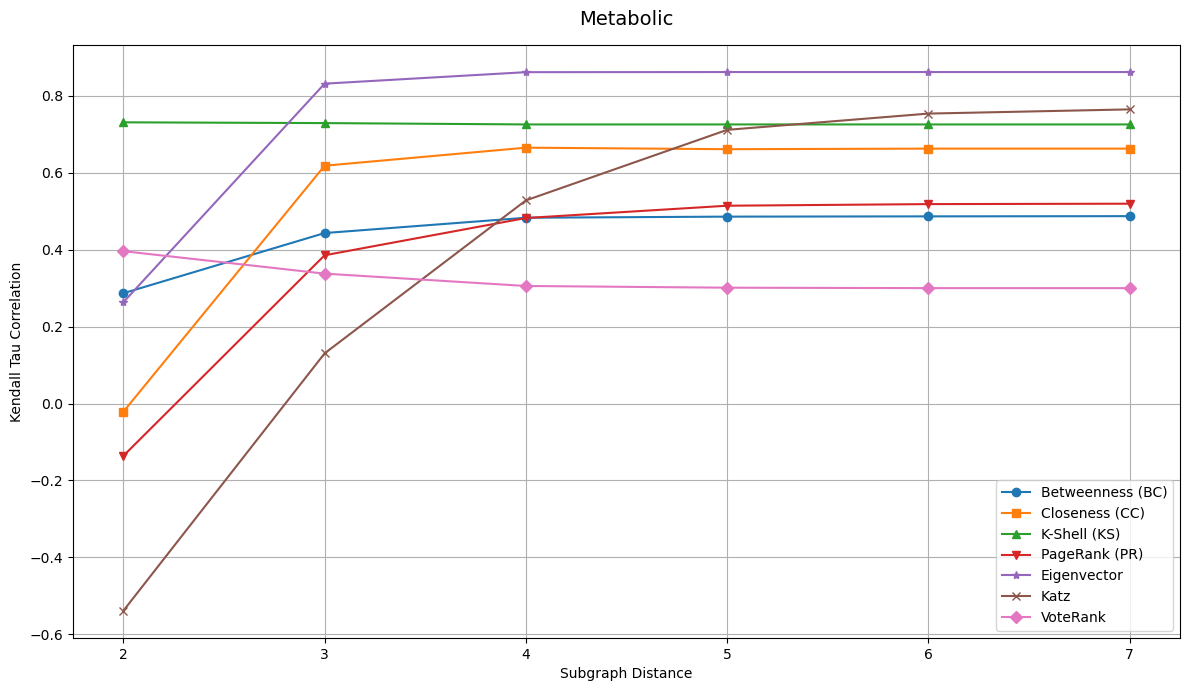

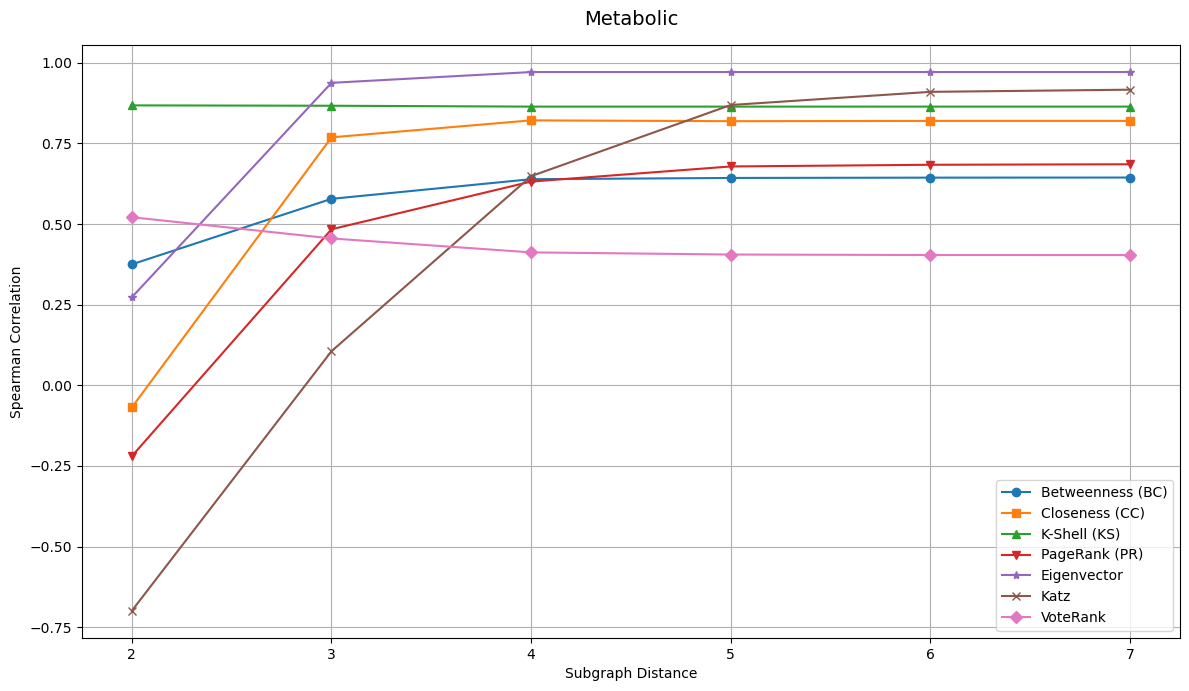

In [46]:
# Convert results to DataFrame
kendall_df = pd.DataFrame(kendall_results)
spearman_df = pd.DataFrame(spearman_results)

#kendall tau correlation
plt.figure(figsize=(12, 7))
plt.plot(kendall_df["Distance"], kendall_df["Betweenness"], marker="o", label="Betweenness (BC)")
plt.plot(kendall_df["Distance"], kendall_df["Closeness"], marker="s", label="Closeness (CC)")
plt.plot(kendall_df["Distance"], kendall_df["K-Shell"], marker="^", label="K-Shell (KS)")
plt.plot(kendall_df["Distance"], kendall_df["PageRank"], marker="v", label="PageRank (PR)")
plt.plot(kendall_df["Distance"], kendall_df["Eigenvector"], marker="*", label="Eigenvector")
plt.plot(kendall_df["Distance"], kendall_df["Katz"], marker="x", label="Katz")
plt.plot(kendall_df["Distance"], kendall_df["VoteRank"], marker="D", label="VoteRank")
plt.xlabel("Subgraph Distance")
plt.ylabel("Kendall Tau Correlation")
#plt.title("Kendall Tau Correlation vs Subgraph Distance")
plt.title(Network_Name, fontsize=14, y=1.02)
plt.legend()
plt.xticks(kendall_df["Distance"])
plt.grid()
plt.tight_layout()
plt.savefig(
    os.path.join("figures", f"kendall_{Network_Name}.pdf"),
    bbox_inches="tight"
)
plt.show()


# Plot Spearman Correlation
plt.figure(figsize=(12, 7))
plt.plot(spearman_df["Distance"], spearman_df["Betweenness"], marker="o", label="Betweenness (BC)")
plt.plot(spearman_df["Distance"], spearman_df["Closeness"], marker="s", label="Closeness (CC)")
plt.plot(spearman_df["Distance"], spearman_df["K-Shell"], marker="^", label="K-Shell (KS)")
plt.plot(spearman_df["Distance"], spearman_df["PageRank"], marker="v", label="PageRank (PR)")
plt.plot(spearman_df["Distance"], spearman_df["Eigenvector"], marker="*", label="Eigenvector")
plt.plot(spearman_df["Distance"], spearman_df["Katz"], marker="x", label="Katz")
plt.plot(spearman_df["Distance"], spearman_df["VoteRank"], marker="D", label="VoteRank")
plt.xlabel("Subgraph Distance")
plt.ylabel("Spearman Correlation")
#plt.title("Spearman Correlation vs Subgraph Distance")
plt.title(Network_Name, fontsize=14, y=1.02)
plt.legend()
plt.xticks(spearman_df["Distance"])
plt.grid()
plt.tight_layout()
plt.savefig(
    os.path.join("figures", f"spearman_{Network_Name}.pdf"),
    bbox_inches="tight"
)
#plt.savefig("Figures/Average_SIR_Dynamics.png",dpi=600,bbox_inches="tight")

plt.show()

In [47]:
#Jaccard Similarity Computation Block
def compute_jaccard(df_full, full_col, df_sub, sub_col, k):

    full_nodes = set(
        df_full.sort_values(
            by=full_col,
            ascending=False
        )["Node"].astype(int).head(k)
    )

    sub_nodes = set(
        df_sub.sort_values(
            by=sub_col,
            ascending=False
        )["Node"].astype(int).head(k)
    )
    print("K :",k)
    #print("FULL :", full_nodes)
    #print("SUB  :", sub_nodes)
    print("INTERSECTION :", full_nodes & sub_nodes)
    return len(full_nodes & sub_nodes) / len(full_nodes | sub_nodes)


In [48]:
import matplotlib.pyplot as plt
import os

def plot_jaccard(df, network_name, title_suffix, ylabel, filename):

    plt.figure(figsize=(12,7))

    plt.plot(df["Distance"], df["Betweenness"], marker="o", label="Betweenness (BC)")
    plt.plot(df["Distance"], df["Closeness"], marker="s", label="Closeness (CC)")
    plt.plot(df["Distance"], df["K-Shell"], marker="^", label="K-Shell (KS)")
    plt.plot(df["Distance"], df["PageRank"], marker="v", label="PageRank (PR)")
    plt.plot(df["Distance"], df["Eigenvector"], marker="*", label="Eigenvector")
    plt.plot(df["Distance"], df["Katz"], marker="x", label="Katz")
    plt.plot(df["Distance"], df["VoteRank"], marker="D", label="VoteRank")

    plt.xlabel("Subgraph Distance")
    #plt.ylabel("Jaccard Similarity")
    plt.ylabel(ylabel)
    plt.title(network_name+title_suffix, fontsize=14, y=1.02)

    plt.xticks(df["Distance"])

    plt.ylim(0,1.05)

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join("figures", filename),
        bbox_inches="tight"
    )

    plt.show()

Network : Metabolic
Diameter: 7
Processing Diameter = 2
Computing Jaccard Similarity against Full Network for K-Shell ::
K : 10
INTERSECTION : {32, 65, 67, 68, 294, 298, 300, 49, 345, 63}
K : 20
INTERSECTION : {3, 4, 32, 294, 167, 298, 300, 49, 187, 63, 65, 193, 67, 68, 345, 351, 102, 103, 231}
K : 30
INTERSECTION : {3, 4, 6, 7, 8, 11, 16, 18, 32, 294, 167, 298, 300, 174, 49, 314, 187, 63, 65, 193, 67, 68, 70, 345, 351, 102, 103, 231, 363, 117}
Computing Jaccard Similarity against SIR for K-Shell ::
K : 10
INTERSECTION : {65, 67, 68}
K : 20
INTERSECTION : {32, 65, 193, 3, 4, 67, 68, 167, 102, 103, 18, 345, 187, 63}
K : 30
INTERSECTION : {3, 4, 6, 7, 8, 11, 16, 18, 32, 294, 167, 298, 300, 174, 49, 187, 63, 65, 193, 67, 68, 70, 345, 102, 103, 231, 117}
Computing Jaccard Similarity against Full Network for Betweenness ::
K : 10
INTERSECTION : {3, 11, 44, 16, 18}
K : 20
INTERSECTION : {32, 3, 4, 67, 103, 11, 44, 16, 18, 155, 158}
K : 30
INTERSECTION : {3, 4, 5, 6, 7, 8, 11, 16, 18, 155, 15

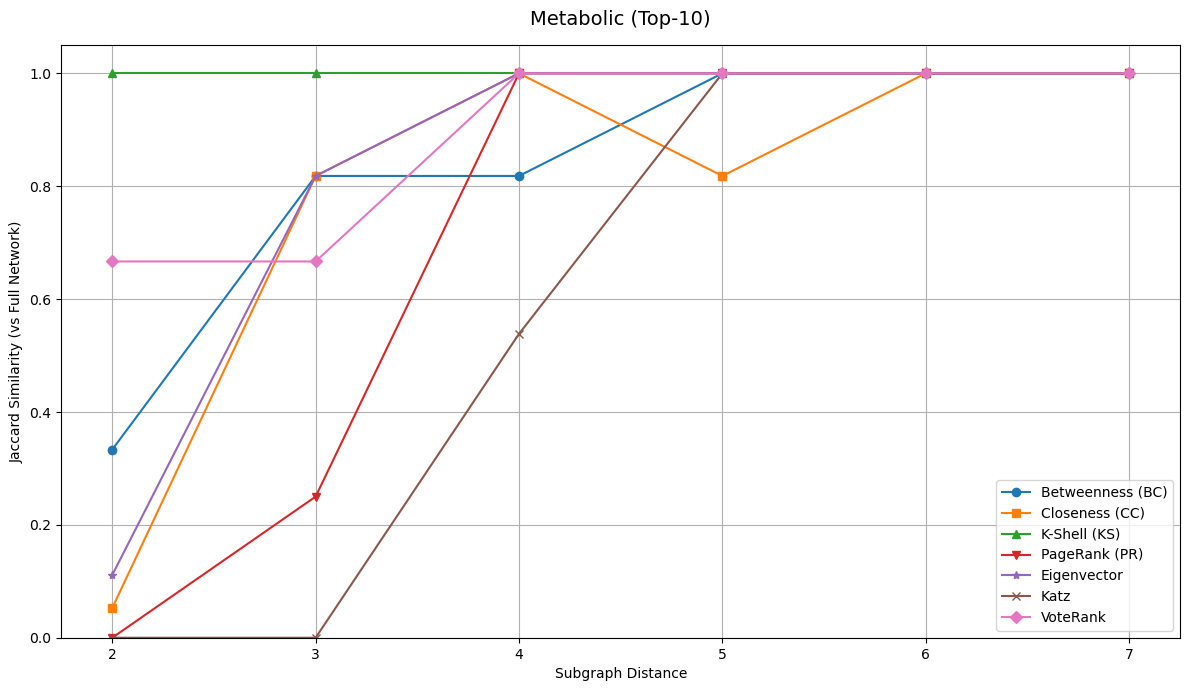

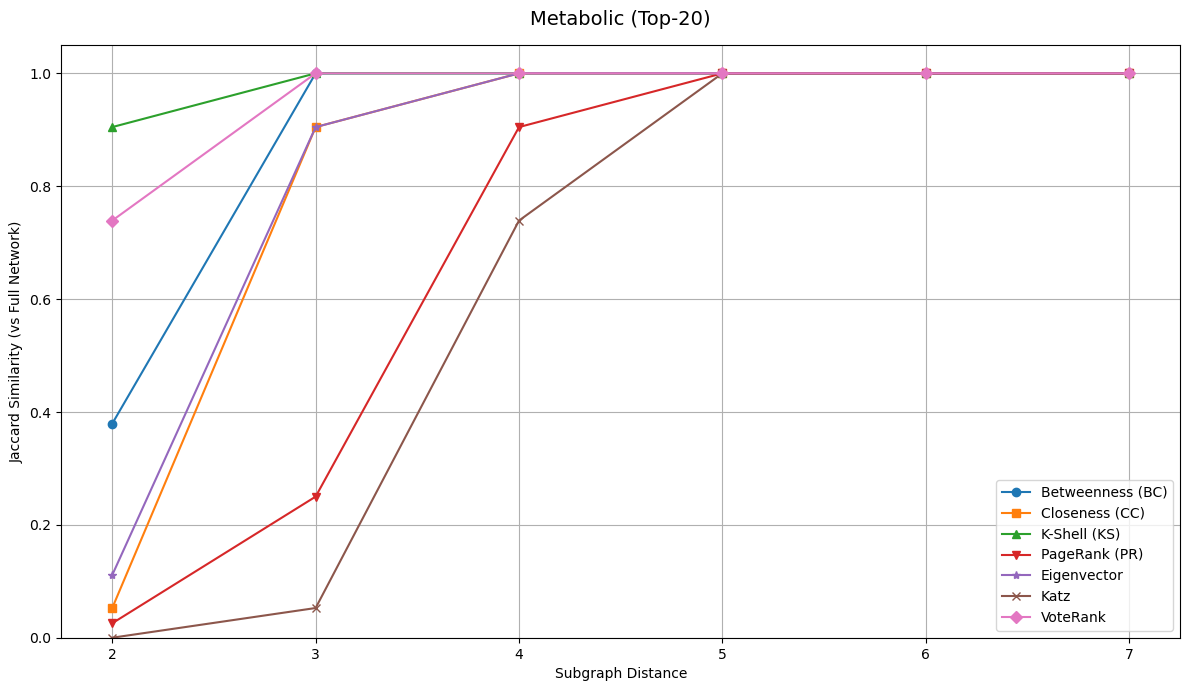

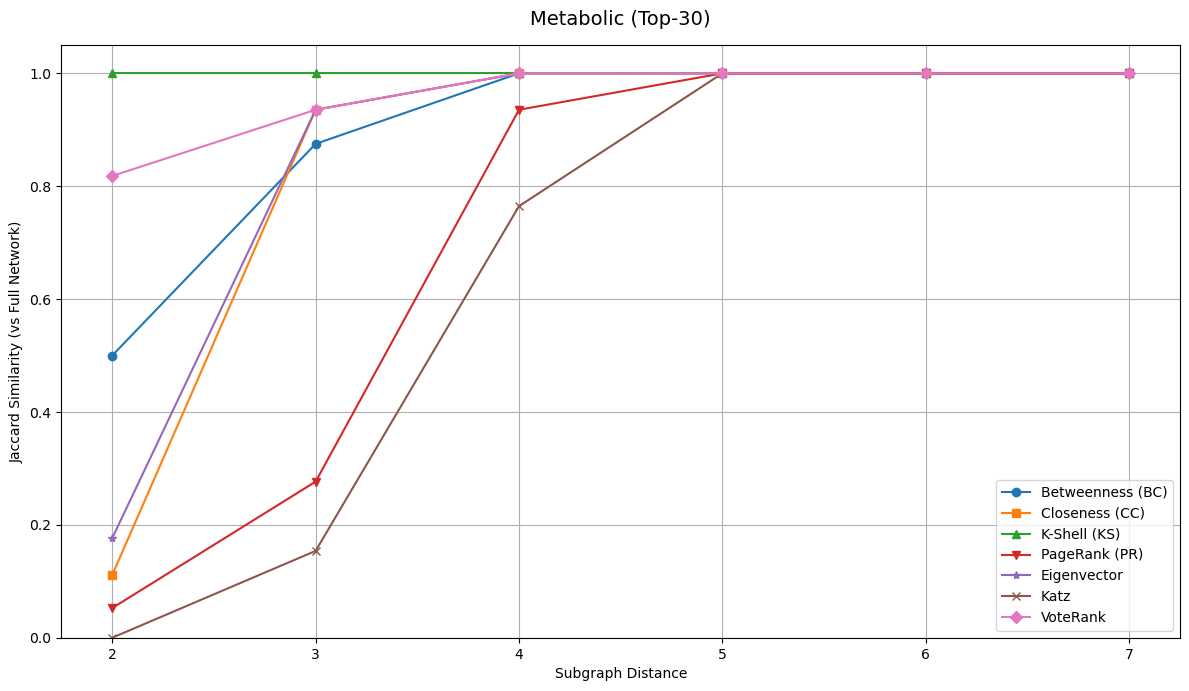

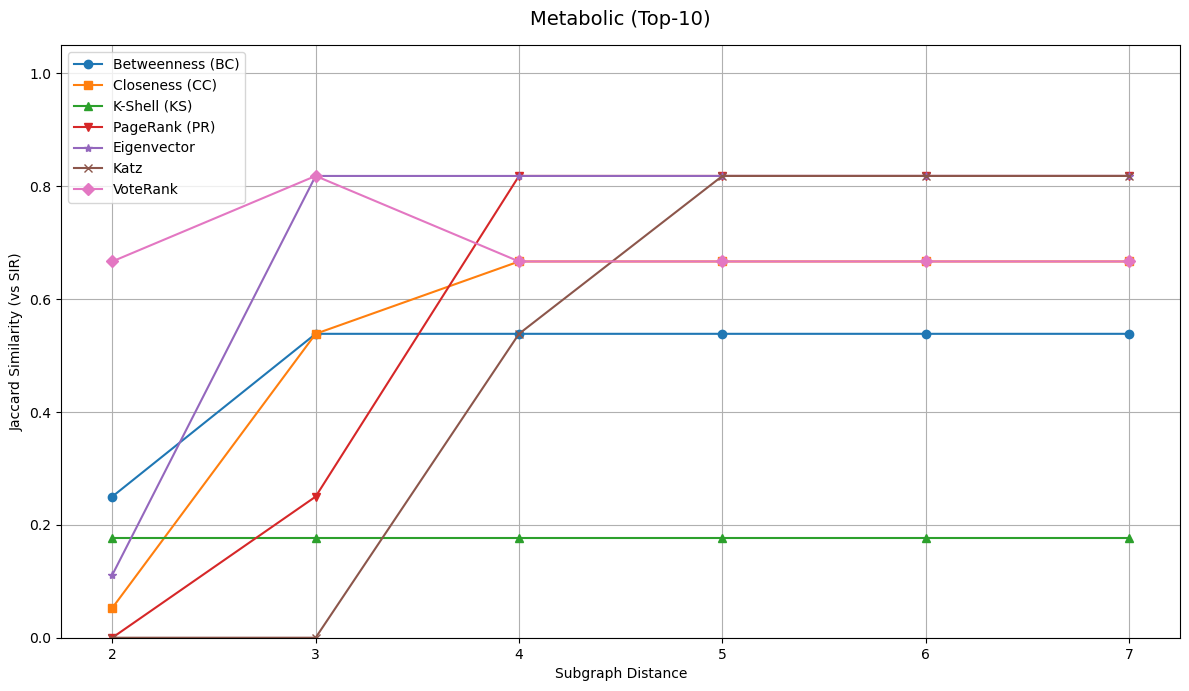

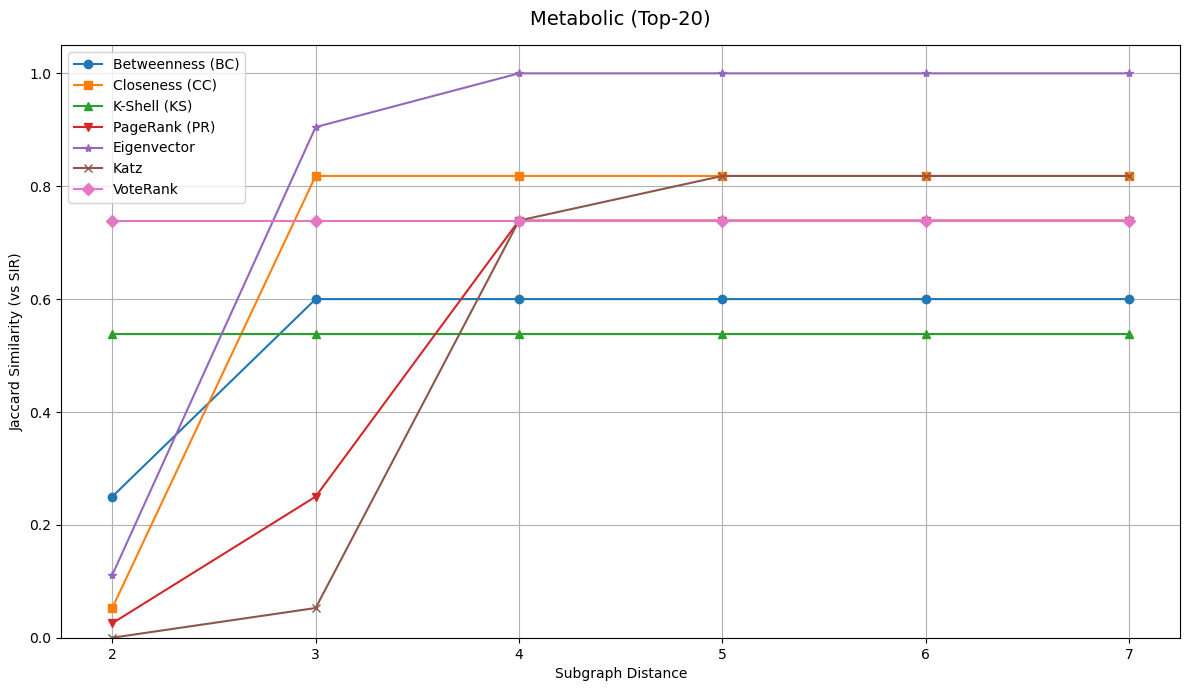

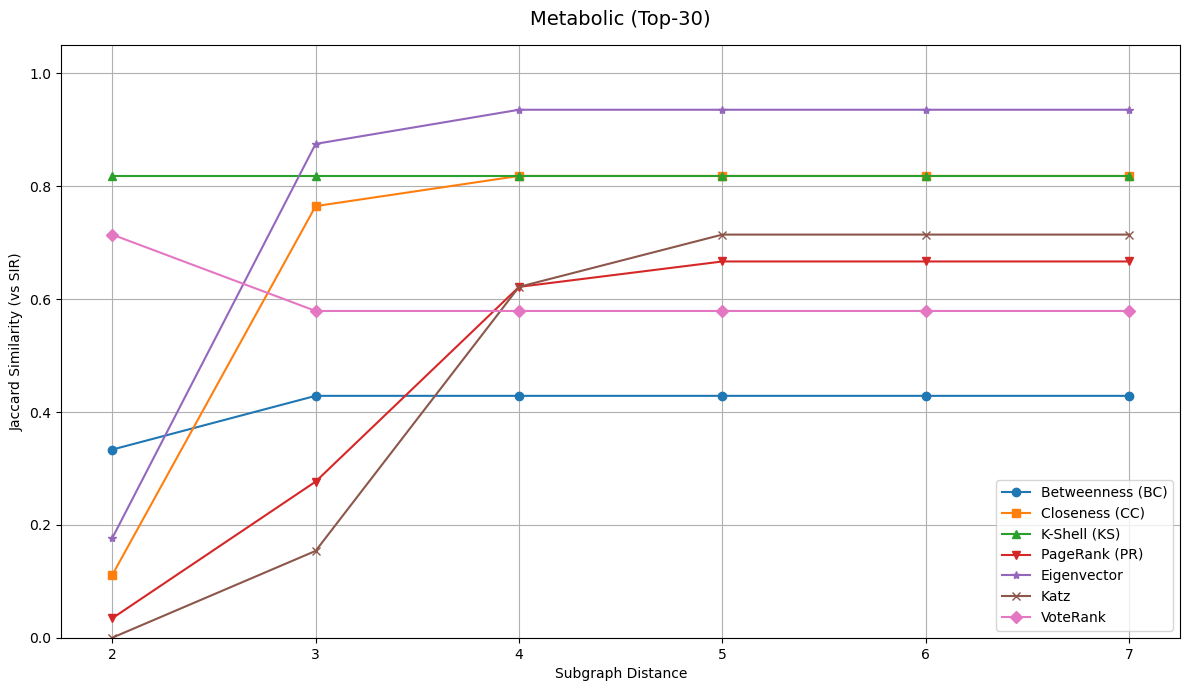

In [49]:
# ============================================================
# JACCARD SIMILARITY COMPUTATION ONLY
# ============================================================

import os

Network_Name = "Metabolic"

csv_file = os.path.join("datasets", f"{Network_Name}_dataset.csv")

G = load_graph(csv_file)
G.remove_edges_from(nx.selfloop_edges(G))
G = get_largest_connected_component(G)

diameter = nx.diameter(G)

print(f"Network : {Network_Name}")
print(f"Diameter: {diameter}")

# ---------------------------------------------------------
# Load already computed full network centralities
# ---------------------------------------------------------

df_full = pd.read_csv(
    os.path.join("results", f"{Network_Name}_all_centrality.csv")
)

centrality_measures = [
    "K-Shell",
    "Betweenness",
    "Closeness",
    "PageRank",
    "Eigenvector",
    "Katz",
    "VoteRank"
]

# ---------------------------------------------------------
# Result storage
# ---------------------------------------------------------

jaccard_full_10 = []
jaccard_full_20 = []
jaccard_full_30 = []

jaccard_sir_10 = []
jaccard_sir_20 = []
jaccard_sir_30 = []

# ---------------------------------------------------------
# Iterate through sampled network diameters
# ---------------------------------------------------------

for d in range(2, diameter + 1):

    print(f"Processing Diameter = {d}")

    df_sub = process_subgraphs(G, d)

    row_full10 = {"Distance": d}
    row_full20 = {"Distance": d}
    row_full30 = {"Distance": d}

    row_sir10 = {"Distance": d}
    row_sir20 = {"Distance": d}
    row_sir30 = {"Distance": d}

    for measure in centrality_measures:

        # ---------- Same Centrality vs Full Network ----------
        print(f"Computing Jaccard Similarity against Full Network for {measure} ::")
        row_full10[measure] = compute_jaccard(
            df_full,
            measure,
            df_sub,
            measure,
            10
        )

        row_full20[measure] = compute_jaccard(
            df_full,
            measure,
            df_sub,
            measure,
            20
        )

        row_full30[measure] = compute_jaccard(
            df_full,
            measure,
            df_sub,
            measure,
            30
        )

        # ---------- Full Network SIR vs Subgraph Centrality ----------
        print(f"Computing Jaccard Similarity against SIR for {measure} ::")
        row_sir10[measure] = compute_jaccard(
            df_full,
            "SIR_Score",
            df_sub,
            measure,
            10
        )

        row_sir20[measure] = compute_jaccard(
            df_full,
            "SIR_Score",
            df_sub,
            measure,
            20
        )

        row_sir30[measure] = compute_jaccard(
            df_full,
            "SIR_Score",
            df_sub,
            measure,
            30
        )

    jaccard_full_10.append(row_full10)
    jaccard_full_20.append(row_full20)
    jaccard_full_30.append(row_full30)

    jaccard_sir_10.append(row_sir10)
    jaccard_sir_20.append(row_sir20)
    jaccard_sir_30.append(row_sir30)

# ---------------------------------------------------------
# Convert to DataFrames
# ---------------------------------------------------------

jaccard_full10_df = pd.DataFrame(jaccard_full_10)
jaccard_full20_df = pd.DataFrame(jaccard_full_20)
jaccard_full30_df = pd.DataFrame(jaccard_full_30)

jaccard_sir10_df = pd.DataFrame(jaccard_sir_10)
jaccard_sir20_df = pd.DataFrame(jaccard_sir_20)
jaccard_sir30_df = pd.DataFrame(jaccard_sir_30)

# ---------------------------------------------------------
# Save CSV files
# ---------------------------------------------------------

jaccard_full10_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_Full_Top10.csv"),
    index=False
)

jaccard_full20_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_Full_Top20.csv"),
    index=False
)

jaccard_full30_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_Full_Top30.csv"),
    index=False
)

jaccard_sir10_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_SIR_Top10.csv"),
    index=False
)

jaccard_sir20_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_SIR_Top20.csv"),
    index=False
)

jaccard_sir30_df.to_csv(
    os.path.join("results", f"{Network_Name}_Jaccard_SIR_Top30.csv"),
    index=False
)

print("Jaccard Similarity Computation Completed.")

plot_jaccard(
    jaccard_full10_df,
    Network_Name,
    " (Top-10)",
    "Jaccard Similarity (vs Full Network)",
    f"Jaccard_Full_Top10_{Network_Name}.pdf"
)

plot_jaccard(
    jaccard_full20_df,
    Network_Name,
    " (Top-20)",
    "Jaccard Similarity (vs Full Network)",
    f"Jaccard_Full_Top20_{Network_Name}.pdf"
)

plot_jaccard(
    jaccard_full30_df,
    Network_Name,
    " (Top-30)",
    "Jaccard Similarity (vs Full Network)",
    f"Jaccard_Full_Top30_{Network_Name}.pdf"
)

plot_jaccard(
    jaccard_sir10_df,
    Network_Name,
    " (Top-10)",
    "Jaccard Similarity (vs SIR)",
    f"Jaccard_SIR_Top10_{Network_Name}.pdf"
)

plot_jaccard(
    jaccard_sir20_df,
    Network_Name,
    " (Top-20)",
    "Jaccard Similarity (vs SIR)",
    f"Jaccard_SIR_Top20_{Network_Name}.pdf"
)

plot_jaccard(
    jaccard_sir30_df,
    Network_Name,
    " (Top-30)",
    "Jaccard Similarity (vs SIR)",
    f"Jaccard_SIR_Top30_{Network_Name}.pdf"
)

In [ ]:
def get_top_seed(centrality_scores):
    """
    Returns the node having the highest centrality score.
    """
    return max(centrality_scores, key=centrality_scores.get)
    
# One sample S,I,R Vs Time plot for the top node based on degree, and other centrality method on full network
import os
Network_Name="Physician"
csv_file = os.path.join("datasets", f"{Network_Name}_dataset.csv")
G = load_graph(csv_file)
G.remove_edges_from(nx.selfloop_edges(G))
G = get_largest_connected_component(G)
# Compute dynamic beta threshold
BETA_THRESHOLD = compute_beta_threshold(G, MU)
BETA = 2 * BETA_THRESHOLD  # Scaled beta

print(f"Computed Beta Threshold: {BETA_THRESHOLD:.6f}")
print(f"Using Beta Value: {BETA:.6f}")

# Simulate SIR model and Plot S,I,R vs time plots

centrality = compute_centrality_measures(G)

for measure in [
        "Betweenness",
        "Closeness",
        "K-Shell",
        "PageRank",
        "Eigenvector",
        "Katz",
        "VoteRank"]:

    seed = get_top_seed(centrality[measure])

    print(f"{measure} Seed = {seed}")

    avgS, avgI, avgR = simulate_Single_Seed_SIR_curve(
                            G,
                            seed,
                            BETA,
                            MU,
                            mc_runs=1000)

    plot_Single_seed_SIR_curve(
            Network_Name+"_"+measure,
            avgS,
            avgI,
            avgR,
            title=rf"{measure} Centrality ($\beta$ = {BETA:.4f}, $\mu$ = {MU}, Seed = {seed})"
    )


In [67]:
# Computing Various network properties
import os
import networkx as nx
Network_Name="Unicode"
csv_file = os.path.join("datasets", f"{Network_Name}_dataset.csv")
G = load_graph(csv_file)
G.remove_edges_from(nx.selfloop_edges(G))
G = get_largest_connected_component(G)
print(f"Network: {Network_Name}")
print(f"No of Vertices |V| = {G.number_of_nodes()}")
print(f"No of Edges |E| = {G.number_of_edges()}")
# 1. Average Degree (Average number of friends per person)
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"avg_degree = {avg_degree}")
# 2. Network Density (How many connections exist out of all possible connections)
density = nx.density(G)
print(f"density = {density}")
# 3. Clustering Coefficient (How often your friends are also friends with each other)
avg_clustering = nx.average_clustering(G)
print(f"avg_clustering = {avg_clustering}")
BETA_THRESHOLD = compute_beta_threshold(G, MU)
print(f"Computed Beta Threshold: {BETA_THRESHOLD:.6f}")

Network: Unicode
No of Vertices |V| = 614
No of Edges |E| = 1245
avg_degree = 4.055374592833876
density = 0.006615619237901919
avg_clustering = 0.08275009430348831
Computed Beta Threshold: 0.049956
